In [9]:
import numpy as np

X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 6, 8, 10], dtype=float)  # Linear relation y = 2x

In [10]:
#Initialize parameters and hyperparameters

theta_0 = 0.0  # Intercept
theta_1 = 0.0  # Slope
learning_rate = 0.01
iterations = 1000
n     = len(X)

In [11]:
for i in range(iterations):

    y_pred = theta_0 + theta_1 * X  # Predictions

    # Compute gradients
    d_theta0 = (2/n) * np.sum(y_pred - y)
    d_theta1 = (2/n) * np.sum((y_pred - y) * X)

    # Update parameters
    theta_0 = theta_0 - learning_rate * d_theta0
    theta_1 = theta_1 - learning_rate * d_theta1

    # Optional: print progress
    if i % 100 == 0:
        mse = np.mean((y - y_pred)**2)
        print(f"Iteration {i}: theta_0 = {theta_0:.4f}, theta_1 = {theta_1:.4f}, MSE = {mse:.4f}")

Iteration 0: theta_0 = 0.1200, theta_1 = 0.4400, MSE = 44.0000
Iteration 100: theta_0 = 0.3655, theta_1 = 1.8988, MSE = 0.0245
Iteration 200: theta_0 = 0.2605, theta_1 = 1.9279, MSE = 0.0124
Iteration 300: theta_0 = 0.1856, theta_1 = 1.9486, MSE = 0.0063
Iteration 400: theta_0 = 0.1323, theta_1 = 1.9634, MSE = 0.0032
Iteration 500: theta_0 = 0.0943, theta_1 = 1.9739, MSE = 0.0016
Iteration 600: theta_0 = 0.0672, theta_1 = 1.9814, MSE = 0.0008
Iteration 700: theta_0 = 0.0479, theta_1 = 1.9867, MSE = 0.0004
Iteration 800: theta_0 = 0.0341, theta_1 = 1.9905, MSE = 0.0002
Iteration 900: theta_0 = 0.0243, theta_1 = 1.9933, MSE = 0.0001


In [12]:
print(f"Linear Regression Model: y = {theta_0:.4f} + {theta_1:.4f}x")

Linear Regression Model: y = 0.0174 + 1.9952x


In [13]:
#Predict on new data

X_new = np.array([6, 7, 8])
y_new_pred = theta_0 + theta_1 * X_new
print("Predictions:", y_new_pred)

Predictions: [11.98848257 13.98366292 15.97884327]


In [14]:
def run_gradient_descent(X, y, method='batch', lr=0.01, iterations=50, batch_size=2):
    theta_0 = 0
    theta_1 = 0
    n = len(X)

    history = []  # store theta values

    for epoch in range(iterations):
        if method == 'batch':
            y_pred = theta_0 + theta_1 * X
            d_theta0 = (2/n) * np.sum(y_pred - y)
            d_theta1 = (2/n) * np.sum((y_pred - y) * X)
            theta_0 -= lr * d_theta0
            theta_1 -= lr * d_theta1

        elif method == 'stochastic':
            for i in range(n):
                xi = X[i]
                yi = y[i]
                y_pred_i = theta_0 + theta_1 * xi
                d_theta0 = 2 * (y_pred_i - yi)
                d_theta1 = 2 * (y_pred_i - yi) * xi
                theta_0 -= lr * d_theta0
                theta_1 -= lr * d_theta1

        elif method == 'mini-batch':
            indices = np.random.permutation(n)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            for start in range(0, n, batch_size):
                end = start + batch_size
                xb = X_shuffled[start:end]
                yb = y_shuffled[start:end]
                y_pred = theta_0 + theta_1 * xb
                d_theta0 = (2/len(xb)) * np.sum(y_pred - yb)
                d_theta1 = (2/len(xb)) * np.sum((y_pred - yb) * xb)
                theta_0 -= lr * d_theta0
                theta_1 -= lr * d_theta1

        history.append((theta_0, theta_1))

    return history


In [15]:
history_batch = run_gradient_descent(X, y, method='batch', lr=0.01, iterations=50)
history_sgd = run_gradient_descent(X, y, method='stochastic', lr=0.01, iterations=50)
history_mini = run_gradient_descent(X, y, method='mini-batch', lr=0.01, iterations=50, batch_size=2)


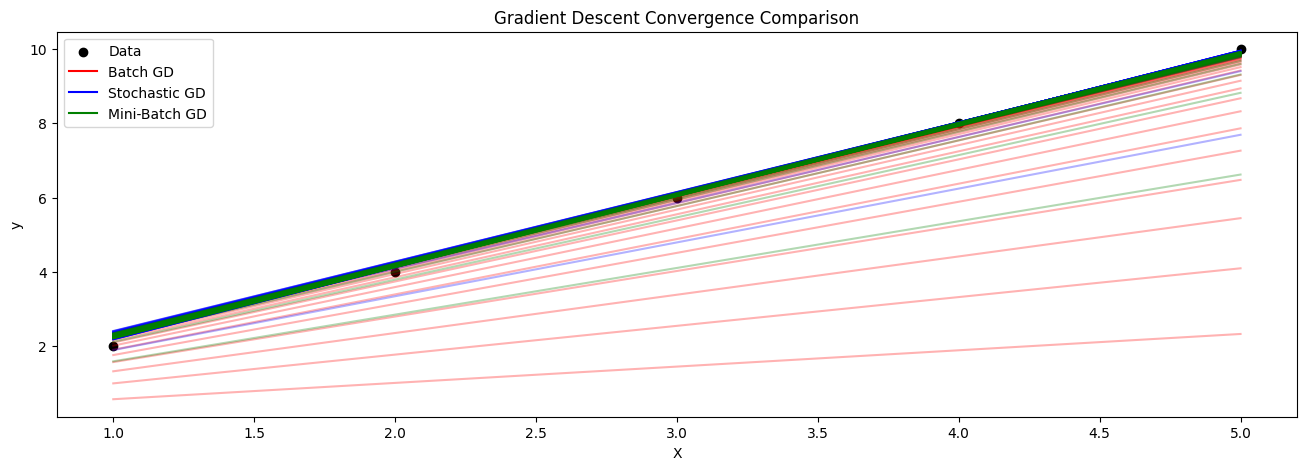

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,5))

# Original data
plt.scatter(X, y, color='black', label='Data')

colors = plt.cm.viridis(np.linspace(0,1,50))

# Batch GD
for i, (t0, t1) in enumerate(history_batch):
    plt.plot(X, t0 + t1*X, color='red', alpha=0.3)
plt.plot(X, history_batch[-1][0] + history_batch[-1][1]*X, color='red', label='Batch GD')

# Stochastic GD
for i, (t0, t1) in enumerate(history_sgd):
    plt.plot(X, t0 + t1*X, color='blue', alpha=0.3)
plt.plot(X, history_sgd[-1][0] + history_sgd[-1][1]*X, color='blue', label='Stochastic GD')

# Mini-Batch GD
for i, (t0, t1) in enumerate(history_mini):
    plt.plot(X, t0 + t1*X, color='green', alpha=0.3)
plt.plot(X, history_mini[-1][0] + history_mini[-1][1]*X, color='green', label='Mini-Batch GD')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Gradient Descent Convergence Comparison')
plt.legend()
plt.show()
